# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")     #loading the dataset

# Data Understanding

In [3]:
df    #showing the dataset attributes

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
df.head()  #to display the first few rows

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.tail()    # to display the last few rows

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [6]:
df.shape

(32581, 12)

In [7]:
df.info()  #to display information about dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [9]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

# Get summary statistics

In [10]:
df.describe()    #statistical summary for numerical columns

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df.describe(include='object')  #statistical summary for categorical columns

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


# Removing Duplicate Records

In [12]:
df.duplicated().sum()   #checking the duplicates

np.int64(165)

In [13]:
df=df.drop_duplicates()  # dropping the duplicate values

In [14]:
df.duplicated().sum()

np.int64(0)

# Checking Missing Values

In [15]:
df.isnull().sum()   # count null values in each column

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
(df.isnull().sum() / len(df)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.736303
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.547754
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

# Understand Categories

In [17]:
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [18]:
for col in cat_cols:
    print(df[col].value_counts())
    print()

person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64



# Handle Missing Values

In [19]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [20]:
df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)    # Filling numerical columns with median
df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)

In [21]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

# Fix Categorical Inconsistencies

In [22]:
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [23]:
for col in cat_cols:
    df[col]=df[col].str.strip().str.lower()   #to remove extra spaces and converting to lower case

In [24]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,rent,123.0,personal,d,35000,16.02,1,0.59,y,3
1,21,9600,own,5.0,education,b,1000,11.14,0,0.10,n,2
2,25,9600,mortgage,1.0,medical,c,5500,12.87,1,0.57,n,3
3,23,65500,rent,4.0,medical,c,35000,15.23,1,0.53,n,2
4,24,54400,rent,8.0,medical,c,35000,14.27,1,0.55,y,4


# Non-Visual Bivariate Analysis

### Categorical vs Categorical

In [25]:
pd.crosstab(df['loan_grade'],df['loan_intent'])

loan_intent,debtconsolidation,education,homeimprovement,medical,personal,venture
loan_grade,,,,,,
a,1740,2157,1122,1944,1822,1918
b,1613,2008,1110,2000,1802,1854
c,1041,1350,691,1212,1044,1100
d,598,656,487,655,643,581
e,144,185,143,167,147,177
f,43,46,32,52,30,38
g,10,9,9,12,10,14


**Observations:**
- Different loan grades are linked to different loan purposes.
- Lower loan grades have more education and medical loans.
- This shows that loan purpose can influence borrower risk.

In [26]:
pd.crosstab(df['person_home_ownership'],df['loan_intent'])

loan_intent,debtconsolidation,education,homeimprovement,medical,personal,venture
person_home_ownership,,,,,,
mortgage,2298,2608,1732,2178,2330,2223
other,17,17,12,17,18,25
own,71,526,317,433,443,773
rent,2803,3260,1533,3414,2707,2661


**Observations:**
- Renters apply more for education and medical loans.
- Homeowners take more education and venture loans.
- Financial stability affects how people use loans.

### Categorical vs Numerical

In [27]:
df.groupby('loan_grade')['loan_status'].mean()

loan_grade
a    0.099598
b    0.163185
c    0.207518
d    0.590608
e    0.644860
f    0.705394
g    0.984375
Name: loan_status, dtype: float64

**Observations:**
- Default rate increases as loan grade goes from A to G.
- Lower loan grades show higher default risk.
- Loan grade is a strong indicator of default risk.

In [28]:
df.groupby('loan_intent')['loan_int_rate'].mean()

loan_intent
debtconsolidation    10.989632
education            10.957958
homeimprovement      11.189900
medical              11.057009
personal             11.002734
venture              10.957168
Name: loan_int_rate, dtype: float64

**Observations:**
- Medical and homeimprovement loans have higher average interest rates
- Interest rates align with default risk levels

In [29]:
df.groupby('person_home_ownership')['person_income'].mean()

person_home_ownership
mortgage    81150.979580
other       76561.273585
own         57858.828326
rent        55019.630663
Name: person_income, dtype: float64

**Observations:**
- People with mortgages earn more because they qualify for large home loans.
- Renters have the lowest average income, which is correct.

### Numerical vs Numerical

In [30]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
corr_matrix=df[num_cols].corr()
corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173293,0.161342,0.050680,0.011074,-0.022698,-0.042300,0.859215
person_income,0.173293,1.000000,0.134791,0.265947,0.000826,-0.145005,-0.254472,0.117614
person_emp_length,0.161342,0.134791,1.000000,0.113934,-0.051462,-0.082517,-0.054024,0.143251
loan_amnt,0.050680,0.265947,0.113934,1.000000,0.139596,0.105736,0.572824,0.041865
loan_int_rate,0.011074,0.000826,-0.051462,0.139596,1.000000,0.320081,0.114411,0.015000
loan_status,-0.022698,-0.145005,-0.082517,0.105736,0.320081,1.000000,0.379697,-0.016498
loan_percent_income,-0.042300,-0.254472,-0.054024,0.572824,0.114411,0.379697,1.000000,-0.031457
cb_person_cred_hist_length,0.859215,0.117614,0.143251,0.041865,0.015000,-0.016498,-0.031457,1.000000


**Observations:**
- Borrowers with a high loan burden and high interest rates are more likely to default.
- Lower loan grades show higher default risk, proving the credit grading system is effective.
- Higher income and longer credit history reduce the chances of loan default.

# Univariate Analysis

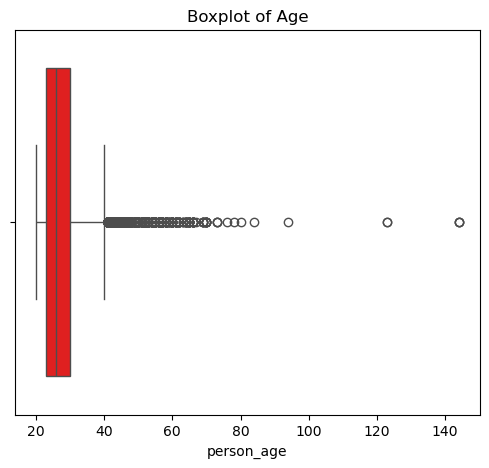

In [31]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['person_age'],color="red")
plt.title('Boxplot of Age')
plt.show()

**Observations:**
- Most borrowers fall within the working-age range, showing the loans are taken mainly by economically active people.
- A few very young and very old borrowers appear as outliers.
- The age distribution is not extremely skewed, meaning loans are spread across different age groups.

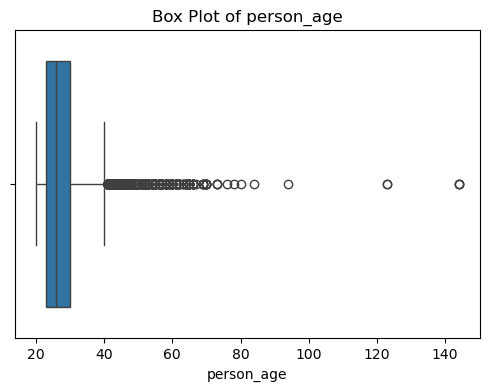

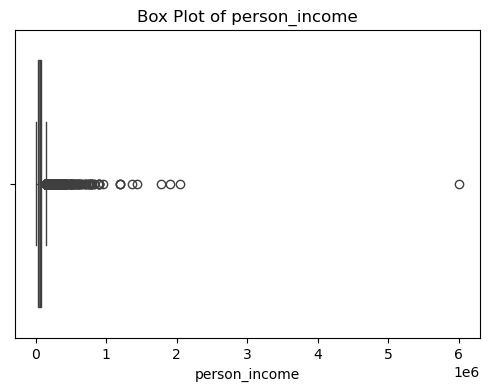

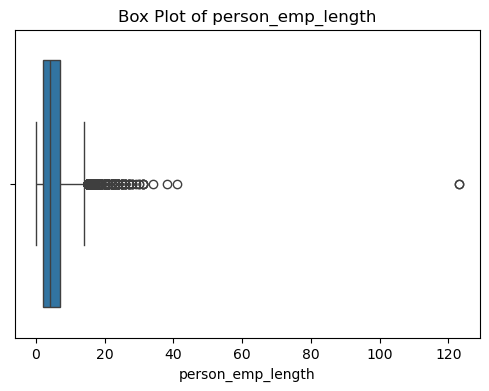

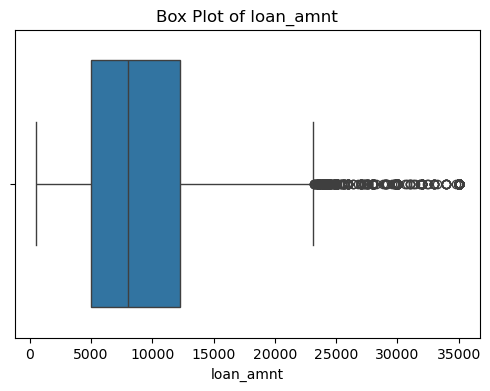

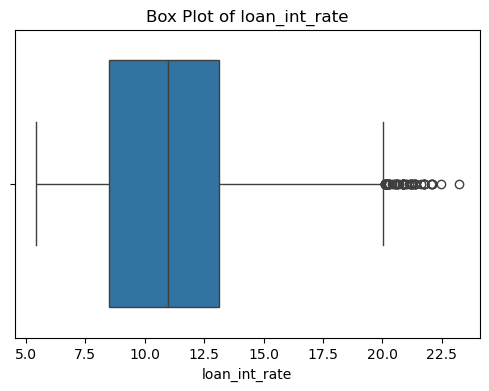

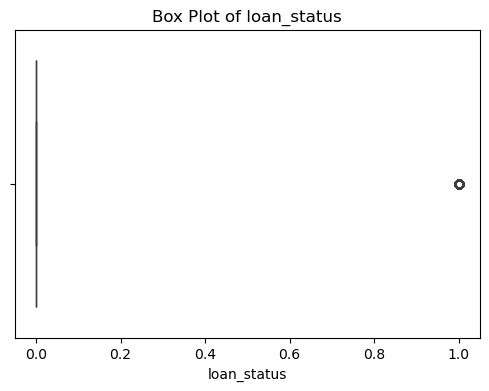

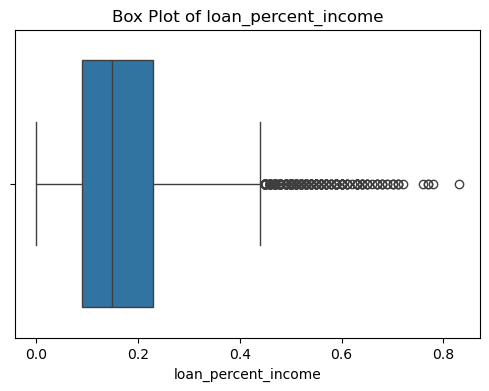

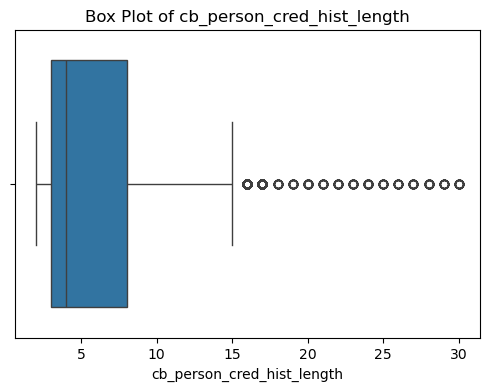

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

**Observations:**
- Most numerical variables show right-skewed distributions,with a few very high values appearing as outliers,especially for income and loan amount.
- Loan amount and income have many high-value outliers,which is expected because some borrowers take large loans and earn high incomes.
- Age and employment length show fewer outliers,indicating more stable and evenly distributed values.
- Interest rate and loan percent income have moderate spread,showing variation in borrower risk levels.
- The outliers are valid business cases and not data errors,so they should not be removed for this financial dataset.

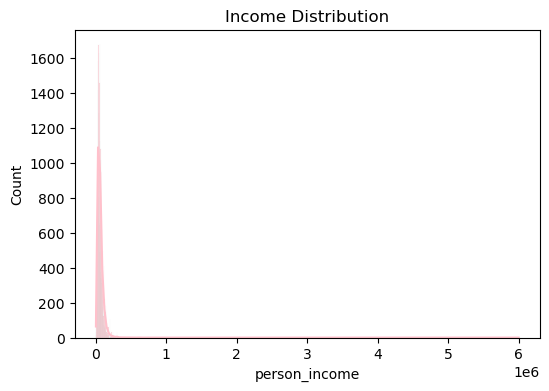

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(df['person_income'],color='pink',kde=True)
plt.title("Income Distribution")
plt.show()

**Observations:**
- Income is right-skewed.
- Most borrowers earn in low to medium income range.
- Few high-income borrowers raise the average income.

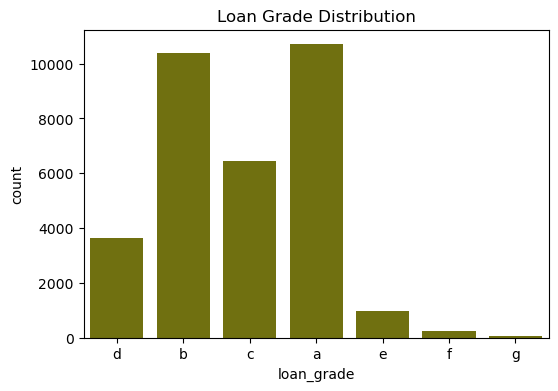

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['loan_grade'],color='olive')
plt.title("Loan Grade Distribution")
plt.show()

**Observations:**
- Grades A and B are most common.
- Higher-risk grades(d-g) have fewer borrowers.
- Majority loans are given to low-risk customers.

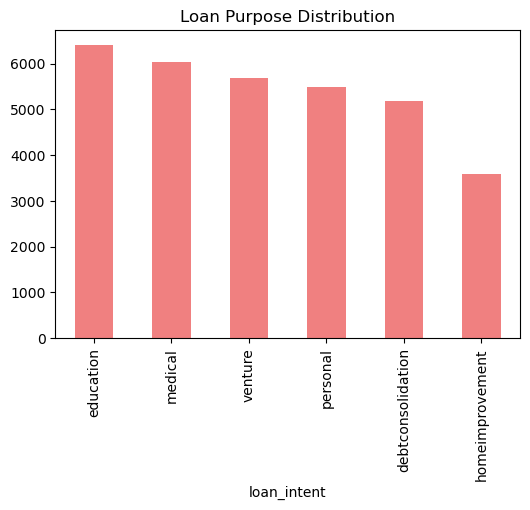

In [39]:
plt.figure(figsize=(6,4))
df['loan_intent'].value_counts().plot(kind='bar',color='lightcoral')
plt.title("Loan Purpose Distribution")
plt.show()

**Observations:**
- Education and medical loans dominate.
- Loan purpose varies across borrowers.
- Purpose influences risk behavior.

# Target Variable Distribution

In [40]:
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

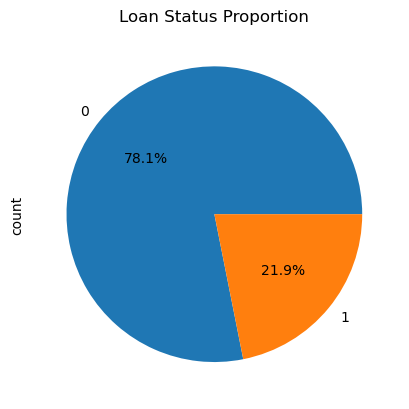

In [42]:
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Loan Status Proportion")
plt.show()

**Observations:**
- Majority of loans are non-default.
- Dataset is imbalanced,which reflects real-world banking data.
- Even though defaults are fewer, they are critical for credit risk analysis.

# Bivariate Analysis

# Num vs Num

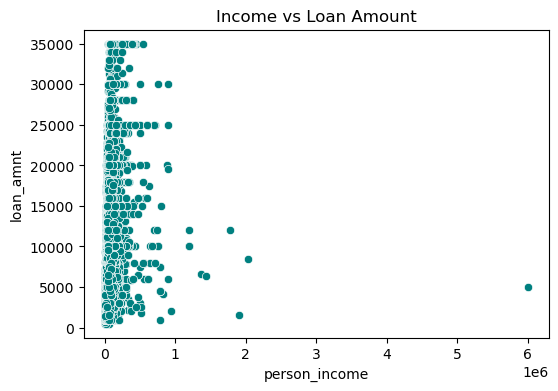

In [44]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['person_income'], y=df['loan_amnt'],color='teal')
plt.title("Income vs Loan Amount")
plt.show()

**Observations:**
- Higher income borrowers take larger loans.
- Lower income borrowers are concentrated around smaller loan amounts.
- Bank considers income while approving loan size.

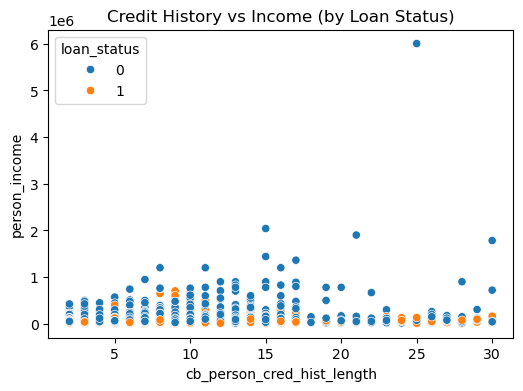

In [81]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['cb_person_cred_hist_length'],y=df['person_income'],hue=df['loan_status'])
plt.title("Credit History vs Income (by Loan Status)")
plt.show()

**Observations:**
- Non-defaulted borrowers have higher income across most credit history lengths.
- Defaulted borrowers are concentrated in lower income ranges.
- Longer credit history combined with higher income reduces default risk.

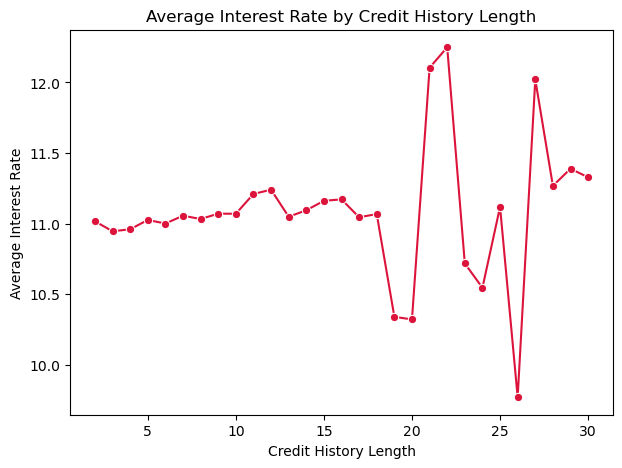

In [52]:
cred_rate = df.groupby('cb_person_cred_hist_length')['loan_int_rate'].mean().reset_index()
plt.figure(figsize=(7,5))
sns.lineplot(x=cred_rate['cb_person_cred_hist_length'],y=cred_rate['loan_int_rate'],color='crimson',marker='o')
plt.title("Average Interest Rate by Credit History Length")
plt.xlabel("Credit History Length")
plt.ylabel("Average Interest Rate")
plt.show()

**Observations:**
- Interest rate decreases as credit history length increases.
- Borrowers with short credit history are charged higher interest rates.
- Lenders offer better interest rates to experienced borrowers.

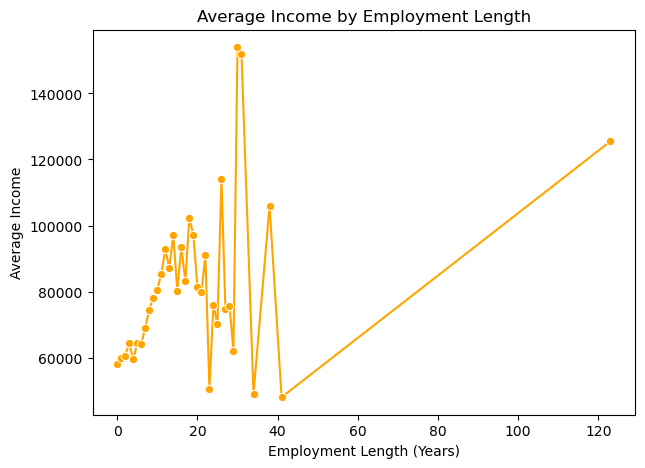

In [60]:
emp_income = df.groupby('person_emp_length')['person_income'].mean().reset_index()
plt.figure(figsize=(7,5))
sns.lineplot(x='person_emp_length',y='person_income',data=emp_income,color='orange',marker='o')
plt.title("Average Income by Employment Length")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Average Income")
plt.show()

**Observations:**
- Average income increases with employment length.
- Borrowers with stable and longer employment earn more.
- Employment stability improves financial strength and repayment ability

# Cat vs Num

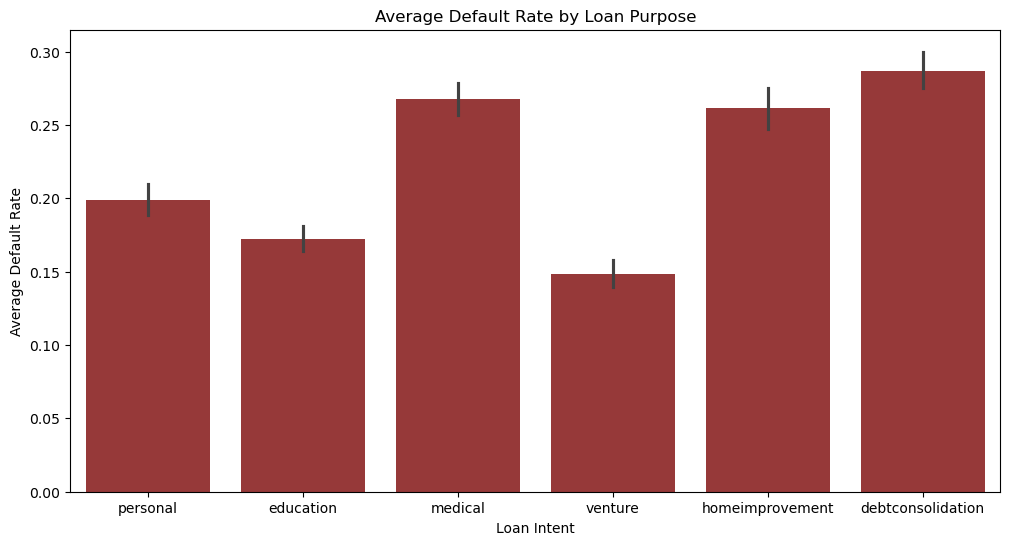

In [83]:
plt.figure(figsize=(12,6))
sns.barplot(x=df['loan_intent'],y=df['loan_status'],color='brown')
plt.title("Average Default Rate by Loan Purpose")
plt.xlabel("Loan Intent")
plt.ylabel("Average Default Rate")
plt.show()

**Observations:**
- Medical and debtconsolidation loans have higher average default rates.
- Education and venture loans show lower default rates.
- Loan purpose strongly influences repayment behavior.

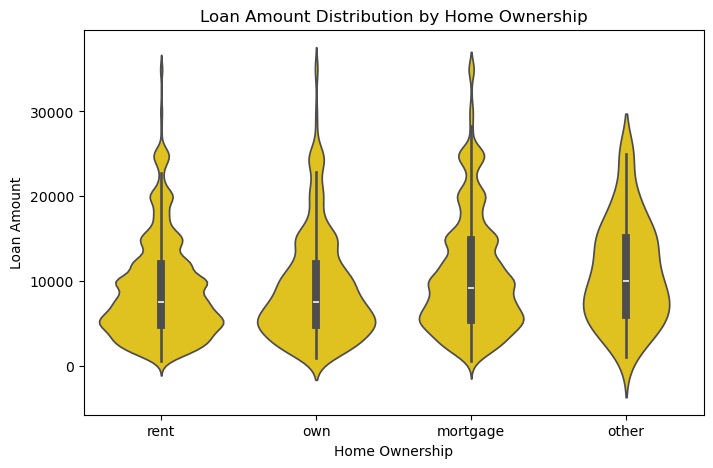

In [93]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df['person_home_ownership'],y=df['loan_amnt'],color='gold')
plt.title("Loan Amount Distribution by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Loan Amount")
plt.show()

**Observations:**
- Homeowners take higher and more varied loan amounts.
- Renters mostly take smaller loans,showing limited borrowing capacity.
- Financial stability affects borrowing capacity.

# Cat vs Cat

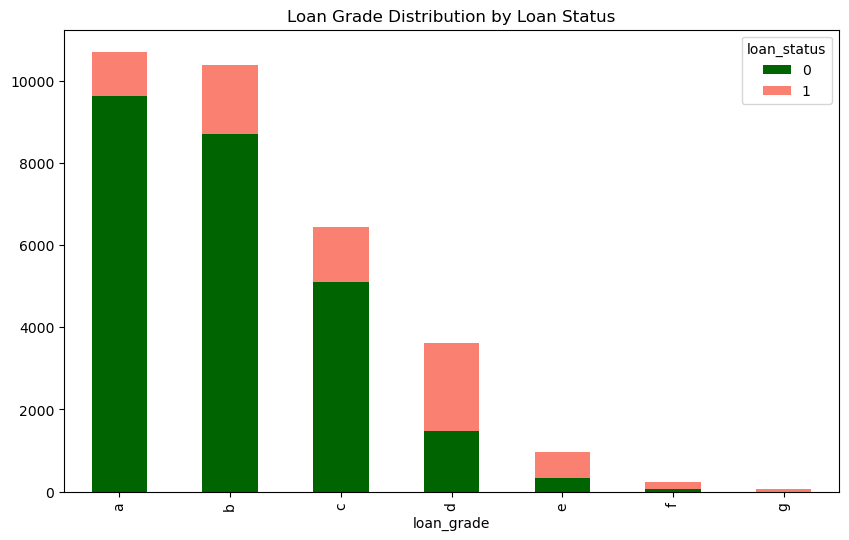

In [103]:
grade_status = pd.crosstab(df['loan_grade'],df['loan_status'])
grade_status.plot(kind='bar',stacked=True,figsize=(10,6),color=['darkgreen','salmon'])
plt.title("Loan Grade Distribution by Loan Status")
plt.show()

**Observations:**
- Lower loan grades (D,E,F,G) have a higher proportion of defaults compared to higher grades.
- Grades A and B show more non-defaulted loans,indicating lower risk.
- As loan grade worsens,the default portion increases,proving that credit grading correctly reflects borrower risk.

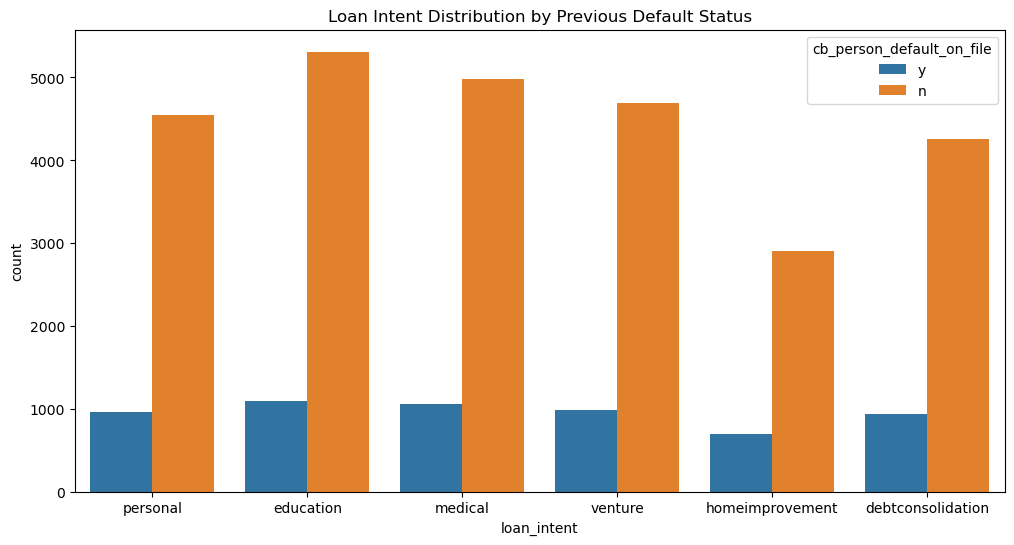

In [106]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['loan_intent'],hue=df['cb_person_default_on_file'])
plt.title("Loan Intent Distribution by Previous Default Status")
plt.show()

**Observations:**
- Borrowers with a previous default on record are more common in medical and education loans.
- Loan purpose is closely related to borrower credit history and risk behavior.

# Multivariate Analysis

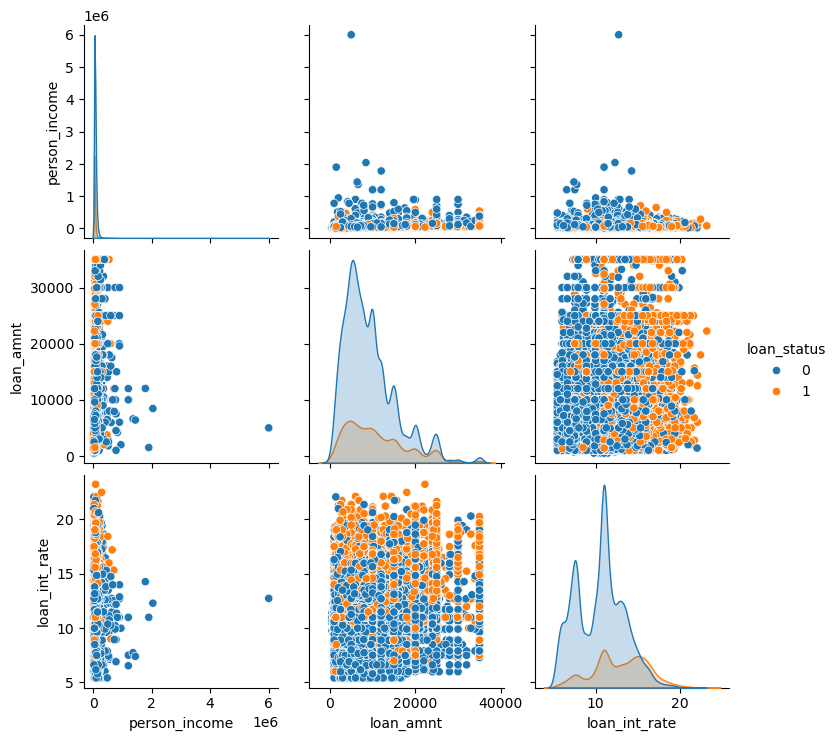

In [88]:
sns.pairplot(df[['person_income','loan_amnt','loan_int_rate','loan_status']],hue='loan_status')
plt.show()

**Observations:**
- Income and loan amount are positively related.
- High interest rates align with defaults.
- Clear separation between risky and safe borrowers.

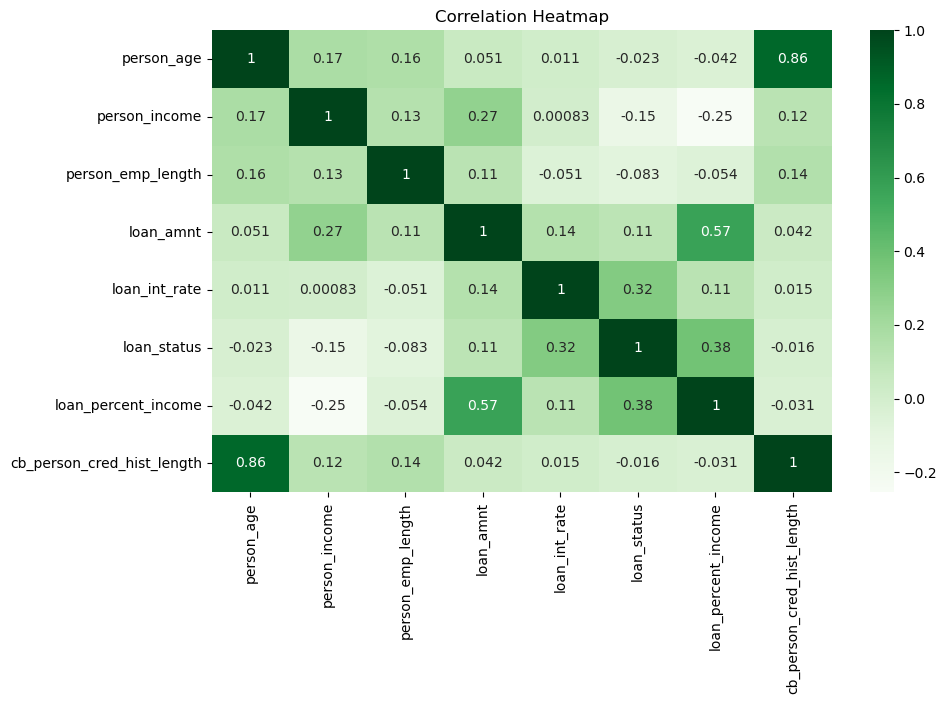

In [89]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')
plt.title("Correlation Heatmap")
plt.show()

**Observations:**
- Loan percent income strongly impacts default.
- Interest rate increases default risk.
- Credit history reduces default risk.
- Income is positively related to loan amount.